In [1]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import open3d as o3d
import glob
import torch.nn.functional as F
from torch_cluster import fps

def hat(phi):
    phi_x = phi[..., 0]
    phi_y = phi[..., 1]
    phi_z = phi[..., 2]
    zeros = torch.zeros_like(phi_x)

    phi_hat = torch.stack([
        torch.stack([zeros, -phi_z,  phi_y], dim=-1),
        torch.stack([phi_z,  zeros, -phi_x], dim=-1),
        torch.stack([-phi_y,  phi_x,  zeros], dim=-1)
    ], dim=-2)
    return phi_hat

def ExpSO3(phi, eps=1e-4):
    theta = torch.norm(phi, dim=-1)
    phi_hat = hat(phi)
    E = torch.eye(3, device=phi.device)
    coef1 = torch.zeros_like(theta)
    coef2 = torch.zeros_like(theta)

    ind = theta < eps

    # strict
    _theta = theta[~ind]
    coef1[~ind] = torch.sin(_theta) / _theta
    coef2[~ind] = (1 - torch.cos(_theta)) / _theta**2

    # approximate
    _theta = theta[ind]
    _theta2 = _theta**2
    _theta4 = _theta**4
    coef1[ind] = 1 - _theta2/6 + _theta4/120
    coef2[ind] = .5 - _theta2/24 + _theta4/720

    coef1 = coef1[..., None, None]
    coef2 = coef2[..., None, None]
    return E + coef1 * phi_hat + coef2 * phi_hat @ phi_hat

def drct_rotation(drct):
    B,P = drct.shape[0], drct.shape[1]
    drct_n = drct / torch.norm(drct, dim=-1, keepdim=True)
    dummy = torch.tensor([[[0.,0.,1.]]], device=drct.device)#1,1,3
    inner = torch.clamp((drct_n * dummy).sum(-1), min=-1, max=1)
    theta = torch.acos(inner)#B,P
    cross_drct = torch.cross(dummy, drct_n, dim=-1)
    cross_drct /= torch.norm(cross_drct,dim=-1,keepdim=True)#B,P,3
    pos_r = ExpSO3(cross_drct * theta.unsqueeze(-1))
    pos_dummy = torch.einsum('bpij, bpjk -> bpik', pos_r, dummy.unsqueeze(-1))
    pos_distance = torch.norm(pos_dummy.squeeze(-1) - drct_n, dim=-1)
    neg_r = ExpSO3(-cross_drct * theta.unsqueeze(-1))
    neg_dummy = torch.einsum('bpij, bpjk -> bpik', neg_r, dummy.unsqueeze(-1))
    neg_distance = torch.norm(neg_dummy.squeeze(-1) - drct_n, dim=-1)

    ret = []
    for b in range(B):
        for p in range(P):
            if neg_distance[b,p] < pos_distance[b,p]:
                ret.append(neg_r[b,p])
            else:
                ret.append(pos_r[b,p])
    ret = torch.stack(ret, dim=0).reshape(B,P,3,3)
    return ret

In [2]:
S_input, S_align, S_align_2, I_cano, I_cano_input, S_seg, I_seg, S_joint, S_drct, S_angl, I_joint, I_drct, I_angl, attn_acc = torch.load('test/1.pt')

In [3]:
b =3
nmask = S_seg.shape[1]
njoint = S_joint.shape[1]
color_list = [[0.5,1,0.5], [1,0.5,0.5], [0.5,0.5,1], [0.75,0.75,0.75]]
attn_acc

tensor([ True,  True,  True,  True,  True,  True, False,  True, False, False,
         True,  True,  True,  True,  True,  True])

In [4]:
#Input
pc_input = S_input[b].detach().cpu().permute(1,0)
pcl_input = o3d.geometry.PointCloud()
pcl_input.points = o3d.utility.Vector3dVector(pc_input)
#Input color
seg_color_input = torch.zeros_like(pc_input)
seg_prob = S_seg[b].permute(1,0).detach().cpu()
for n in range(seg_color_input.shape[0]):
    seg_color_input[n] += seg_prob[n,0] * torch.tensor([0.5,1,0.5])
    seg_color_input[n] += seg_prob[n,1] * torch.tensor([1,0.5,0.5])
    if nmask == 3:
        seg_color_input[n] += seg_prob[n,2] * torch.tensor([0.5,0.5,1])
pcl_input.colors = o3d.utility.Vector3dVector(seg_color_input)

#cano
pc_cano = I_cano[b].reshape(3,-1).permute(1,0).detach().cpu()
pcl_cano = o3d.geometry.PointCloud()
pcl_cano.points = o3d.utility.Vector3dVector(pc_cano)
pcl_cano.paint_uniform_color([0.25,0.25,0.25])
#cano to input
pc_cano_input = I_cano_input[b].reshape(3,-1).permute(1,0).detach().cpu()
pcl_cano_input = o3d.geometry.PointCloud()
pcl_cano_input.points = o3d.utility.Vector3dVector(pc_cano_input)
pcl_cano_input.translate([1,0,0])
#cano color
seg_color_cano = torch.zeros_like(pc_cano_input)
seg_prob = I_seg[b].permute(1,0).detach().cpu()
for n in range(seg_color_cano.shape[0]):
    seg_color_cano[n] += seg_prob[n,0] * torch.tensor([0.5,1,0.5])
    seg_color_cano[n] += seg_prob[n,1] * torch.tensor([1,0.5,0.5])
    if nmask == 3:
        seg_color_cano[n] += seg_prob[n,2] * torch.tensor([0.5,0.5,1])
pcl_cano_input.colors = o3d.utility.Vector3dVector(seg_color_cano)

#input to cano
pc_input_cano = S_align[b].detach().cpu().permute(1,0)
pcl_input_cano = o3d.geometry.PointCloud()
pcl_input_cano.points = o3d.utility.Vector3dVector(pc_input_cano)
#pcl_input_cano.colors = o3d.utility.Vector3dVector(seg_color_input)
pcl_input_cano.paint_uniform_color([0.5,0.5,0.5])
#pcl_input_cano.translate([1,0,0])
#cano align
pc_input_align = S_align_2[b].detach().cpu().permute(0,2,1)#P,M,3
pcl_input_align_list = []
for p in range(pc_input_align.shape[0]):
    pcl_cano_align = o3d.geometry.PointCloud()
    pcl_cano_align.points = o3d.utility.Vector3dVector(pc_input_align[p])
    pcl_cano_align.paint_uniform_color(color_list[p])
    pcl_input_align_list.append(pcl_cano_align)

#joint
S_joints = []
joint_rotation = drct_rotation(S_drct)[b]
for i in range(njoint):
    joint = o3d.geometry.TriangleMesh.create_arrow(cylinder_radius=0.005, cone_radius=0.01, cylinder_height=0.20, cone_height=0.05)
    joint.rotate(joint_rotation[i], center=False)
    joint.translate(S_joint[b][i])
    joint.paint_uniform_color([1,0,0])
    if i == 1:
        joint.paint_uniform_color([0,0,1])
    S_joints.append(joint)

I_joints = []
joint_rotation = drct_rotation(I_drct)[b]
for i in range(njoint):
    joint = o3d.geometry.TriangleMesh.create_arrow(cylinder_radius=0.005, cone_radius=0.01, cylinder_height=0.20, cone_height=0.05)
    joint.rotate(joint_rotation[i], center=False)
    joint.translate(I_joint[b][i])
    joint.paint_uniform_color([0.5,0,0])
    if i == 1:
        joint.paint_uniform_color([0,0,0.5])
    I_joints.append(joint)

In [5]:
coor = o3d.geometry.TriangleMesh.create_coordinate_frame(1)
o3d.visualization.draw_geometries([pcl_input, pcl_cano_input, coor])

In [6]:
pcl_input_align_list[0].normals = o3d.utility.Vector3dVector(10*(np.asarray(pcl_input_align_list[1].points) - np.asarray(pcl_input_align_list[0].points)))
o3d.visualization.draw_geometries([*pcl_input_align_list, *S_joints, pcl_cano, *I_joints])
#o3d.visualization.draw_geometries([*pcl_input_align_list, pcl_input_cano, *S_joints, *I_joints])

In [36]:
I_drct[b], S_drct[b], S_angl[b]*180/torch.pi, I_angl[b]*180/torch.pi

(tensor([[-0.6826, -0.0594,  0.7284]]),
 tensor([[-0.7833, -0.2327,  0.5764]]),
 tensor([[-20.1583,  -8.5793]]),
 tensor([[-0.6333,  0.3858]]))

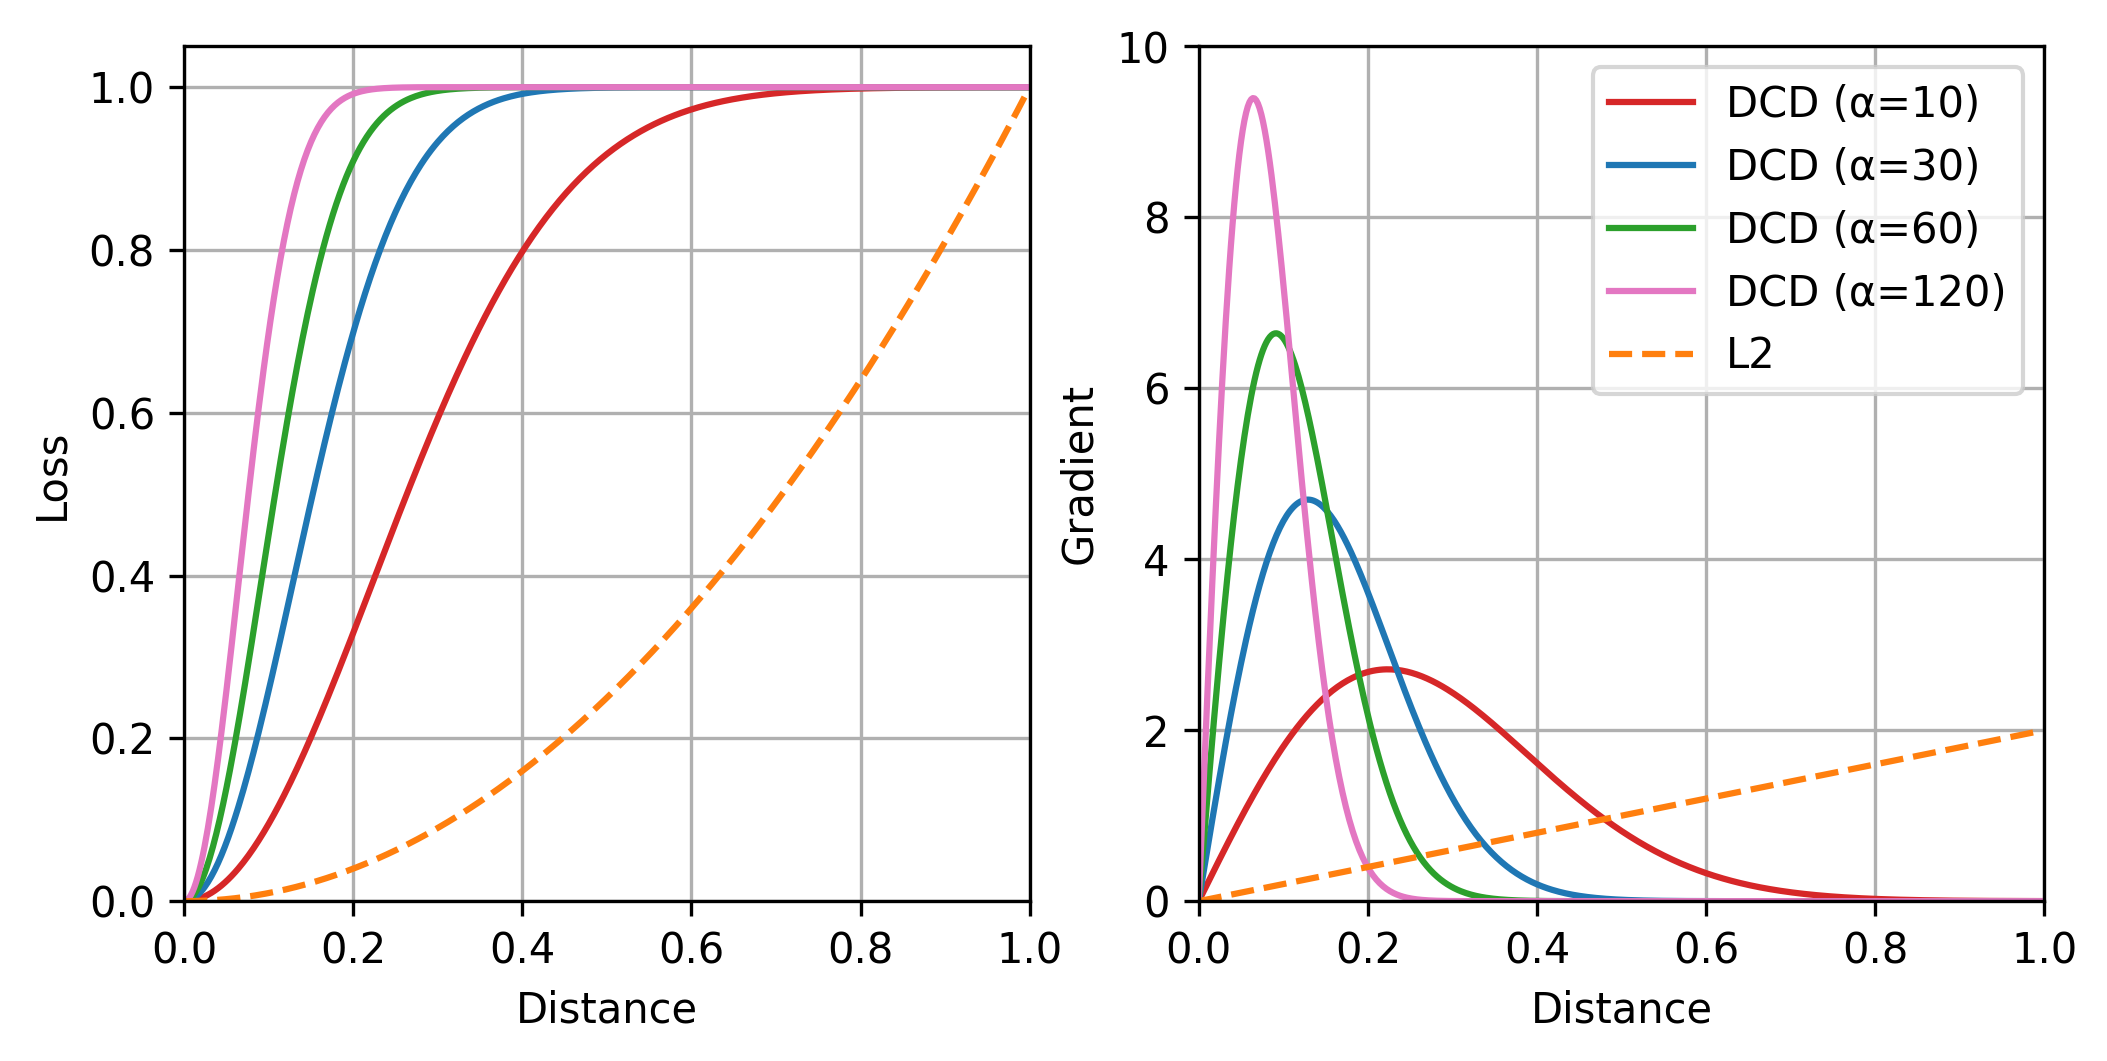

In [4]:
x = np.arange(0,1,0.002)
y_10 = 1 - np.exp(-10 * x ** 2)
y_30 = 1 - np.exp(-30 * x ** 2)
y_60 = 1 - np.exp(-60 * x ** 2)
y_120 = 1 - np.exp(-120 * x ** 2)
y_L2 = x**2
y_L1 = x
z_10 = 10 * np.exp(-10 * x ** 2) * 2 * x
z_30 = 30 * np.exp(-30 * x ** 2) * 2 * x
z_60 = 60 * np.exp(-60 * x ** 2) * 2 * x
z_120 = 120 * np.exp(-120 * x ** 2) * 2 * x
z_L2 = 2 * x
z_L1 = np.ones_like(x)

fig = plt.figure(figsize=(8,3.7), dpi=300)
plt.tight_layout()

ax = plt.subplot(121)
ax.set_ylabel('Loss')
ax.set_xlabel('Distance')
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 1)
#ax.xaxis.set_ticks([0.25, 0.5, 0.75, 1])
ax.grid()
ax.plot(x,y_10, label='DCD10', color='tab:red')
ax.plot(x,y_30, label='DCD30', color='tab:blue')
ax.plot(x,y_60, label='DCD60', color='tab:green')
ax.plot(x,y_120, label='DCD100', color='tab:pink')
ax.plot(x,y_L2, label='L2', linestyle='--', color='tab:orange')

ax = plt.subplot(122)
ax.set_ylabel('Gradient')
ax.set_xlabel('Distance')
ax.set_ylim(0, 10)
ax.set_xlim(0, 1)
#ax.xaxis.set_ticks([0.25, 0.5, 0.75, 1])
ax.grid()
ax.plot(x,z_10, label='DCD (α=10)', color='tab:red')
ax.plot(x,z_30, label='DCD (α=30)', color='tab:blue')
ax.plot(x,z_60, label='DCD (α=60)', color='tab:green')
ax.plot(x,z_120, label='DCD (α=120)', color='tab:pink')
ax.plot(x,z_L2, label='L2', linestyle='--', color='tab:orange')
ax.legend()

plt.savefig('dcd.pdf')

In [31]:
curve_mean_list = []

In [36]:
cate_list = [
    ['basket', 'tab:red', 'log/basket/basket_5_10000/csv/basket_5_10000_eval.csv'],
    ['drawer', 'tab:green', 'log/drawer/drawer_5_10000/model_20240305_143006/csv/drawer_5_10000_eval.csv'],
    ['laptop', 'tab:blue', 'log/laptop/laptop_best/csv/laptop_best_eval.csv'],
    ['scissor', 'tab:orange', 'log/scissor/scissor_best/csv/scissor_best_eval.csv'],
    ['suitcase', 'tab:pink', 'log/suitcase/suitcase_best/csv/suitcase_best_eval.csv'],
]

#cate_list = [
#    ['basket', 'tab:red', '/mnt/c/Users/che/Desktop/3dgcn/basket_3dgcnA_eval.csv'],
#    ['drawer', 'tab:green', '/mnt/c/Users/che/Desktop/3dgcn/drawer_3dgcnA_eval.csv'],
#    ['laptop', 'tab:blue', '/mnt/c/Users/che/Desktop/3dgcn/laptop_3dgcnA_eval.csv'],
#    ['scissor', 'tab:orange', '/mnt/c/Users/che/Desktop/3dgcn/scissor_3dgcnA_eval.csv'],
#    ['suitcase', 'tab:pink', '/mnt/c/Users/che/Desktop/3dgcn/suitcase_3dgcnA_eval.csv'],
#]

#cate_list = [
#    ['basket', 'tab:red', '/mnt/c/Users/che/Desktop/PN/basket_PN_eval.csv'],
#    ['drawer', 'tab:green', '/mnt/c/Users/che/Desktop/PN/drawer_PN_eval.csv'],
#    ['laptop', 'tab:blue', '/mnt/c/Users/che/Desktop/PN/laptop_PN_eval.csv'],
#    ['scissor', 'tab:orange', '/mnt/c/Users/che/Desktop/PN/scissor_PN_eval.csv'],
#    ['suitcase', 'tab:pink', '/mnt/c/Users/che/Desktop/PN/suitcase_PN_eval.csv'],
#]

cate_n = cate_list.__len__()

In [37]:
curve_list= []

s_curve_mean = np.zeros(101)
c_curve_mean = np.zeros(301)
d_curve_mean = np.zeros(181)
r_curve_mean = np.zeros(181)
t_curve_mean = np.zeros(301)

for i in range(cate_n):
    f = pd.read_csv(cate_list[i][2])
    cnt = len(f)

    if 'rotation_2' not in f.keys():
        s = 0.5 * (f['seg_0'] + f['seg_1'])
        c = f['joint_0']
        d = f['direction_0']
        r = 0.5 * (f['rotation_0'] + f['rotation_1'])
        t = 0.5 * (f['translation_0'] + f['translation_1'])
    else:
        s = (f['seg_0'] + f['seg_1'] + f['seg_2']) / 3
        c = (f['joint_0'] + f['joint_1']) / 2
        d = (f['direction_0'] + f['direction_1']) / 2
        r = (f['rotation_0'] + f['rotation_1'] + f['rotation_2']) / 3
        t = (f['translation_0'] + f['translation_1'] + f['translation_2']) / 3

    s_curve = np.zeros(101)
    for i in range(101):
        s_curve[i] = sum(100*s > i) / cnt
    c_curve = np.zeros(301)
    for i in range(301):
        c_curve[i] = sum(10*c < i/10) / cnt
    d_curve = np.zeros(181)
    for i in range(181):
        d_curve[i] = sum(d < i) / cnt
    r_curve = np.zeros(181)
    for i in range(181):
        r_curve[i] = sum(r < i) / cnt
    t_curve = np.zeros(301)
    for i in range(301):
        t_curve[i] = sum(10*t < i/10) / cnt
        
    curve_list.append({
        's': s_curve,
        'c': c_curve,
        'd': d_curve,
        'r': r_curve,
        't': t_curve,
        })
    s_curve_mean += 0.2 * s_curve
    c_curve_mean += 0.2 * c_curve
    d_curve_mean += 0.2 * d_curve
    r_curve_mean += 0.2 * r_curve
    t_curve_mean += 0.2 * t_curve

curve_mean_list.append({
        's': s_curve_mean,
        'c': c_curve_mean,
        'd': d_curve_mean,
        'r': r_curve_mean,
        't': t_curve_mean,
        })

In [40]:
cate_list = [
    ['PointNet++', 'tab:blue', 'log/drawer/drawer_5_10000/model_20240305_143006/csv/drawer_5_10000_eval.csv'],
    ['3DGCN', 'tab:red', 'log/basket/basket_5_10000/csv/basket_5_10000_eval.csv'],
    ['Ours', 'tab:green', '/home/che/workspace/E2PN/log/laptop/laptop_best/csv/laptop_best_eval.csv'],
]
cate_n = cate_list.__len__()

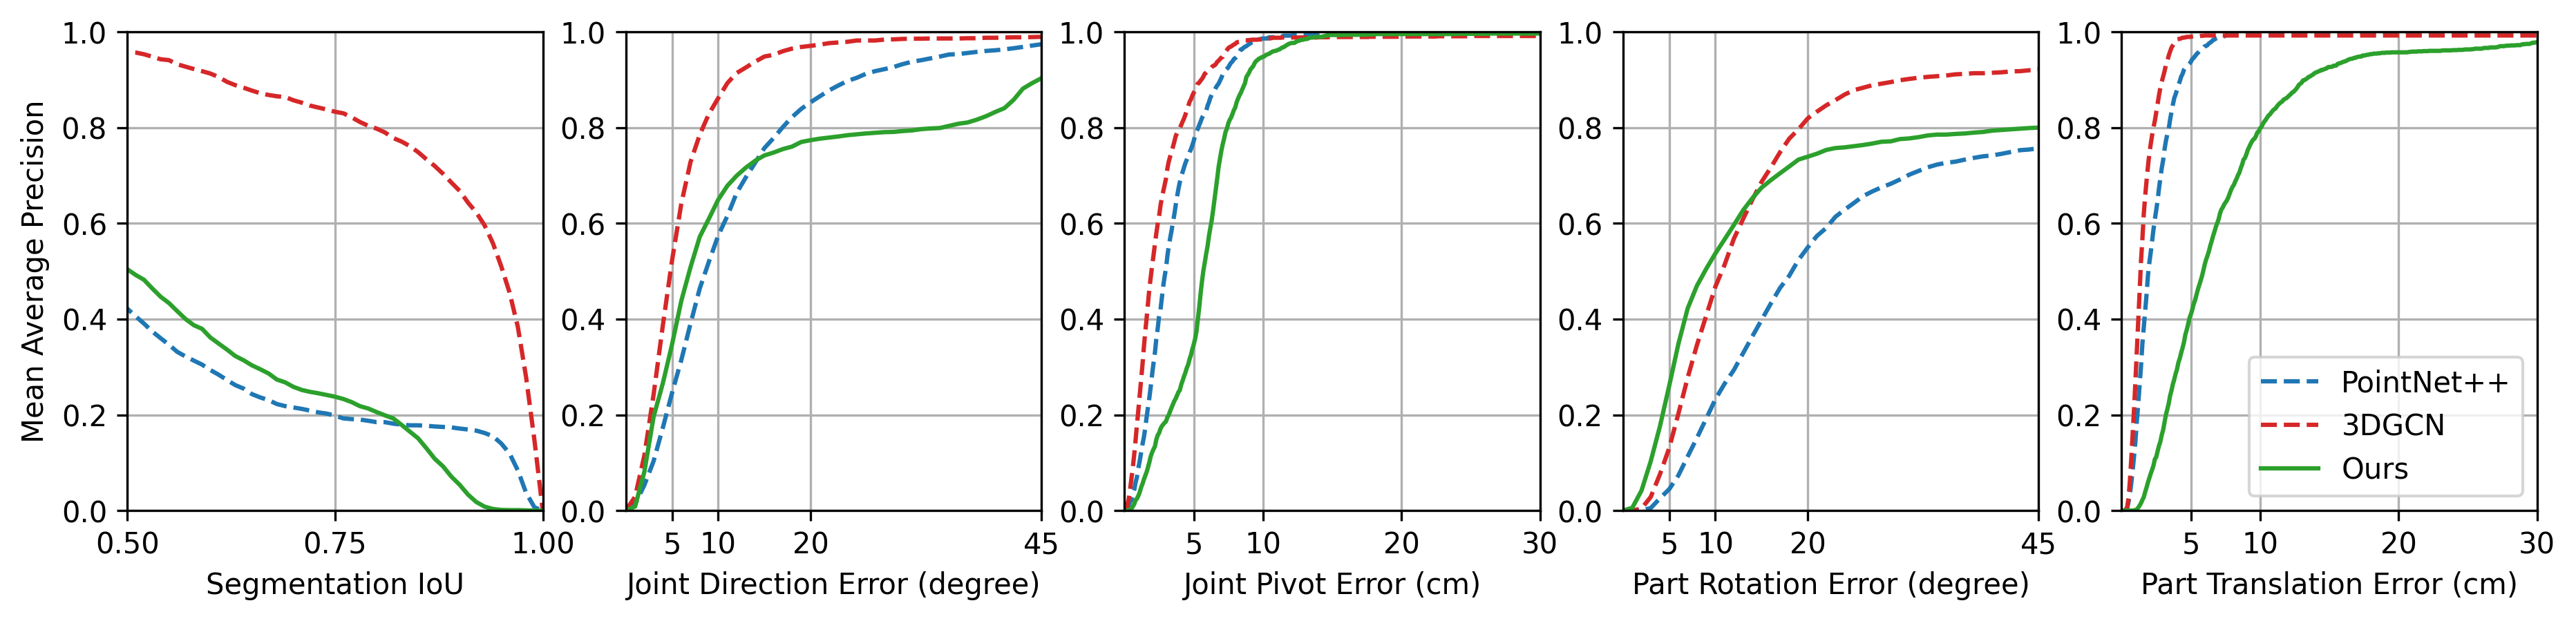

In [42]:
fig = plt.figure(figsize=(15,3), dpi=300)

plt.tight_layout()
ax_iou = plt.subplot(151)
ax_iou.set_ylabel('Mean Average Precision')
ax_iou.set_xlabel('Segmentation IoU')
ax_iou.set_ylim(0, 1)
ax_iou.set_xlim(0.5, 1)
ax_iou.xaxis.set_ticks([0.5, 0.75, 1])
ax_iou.grid()
for i in range(cate_n):
    ax_iou.plot(np.arange(0,1.01,0.01), curve_mean_list[i]['s'], '--' if i in [0,1] else '-', label=cate_list[i][0], color=cate_list[i][1])

ax_d = plt.subplot(152)
ax_d.set_xlabel('Joint Direction Error (degree)')
ax_d.set_ylim(0, 1)
ax_d.set_xlim(0, 45)
ax_d.xaxis.set_ticks([5, 10, 20, 45])
ax_d.grid()
for i in range(cate_n):
    ax_d.plot(np.arange(0,181,1), curve_mean_list[i]['d'], '--' if i in [0,1] else '-', label=cate_list[i][0], color=cate_list[i][1])

ax_c = plt.subplot(153)
ax_c.set_xlabel('Joint Pivot Error (cm)')
ax_c.set_ylim(0, 1)
ax_c.set_xlim(0, 30)
ax_c.xaxis.set_ticks([5, 10, 20, 30])
ax_c.grid()
for i in range(cate_n):
    ax_c.plot(np.arange(0,30.1,0.1), curve_mean_list[i]['c'], '--' if i in [0,1] else '-', label=cate_list[i][0], color=cate_list[i][1])

ax_r = plt.subplot(154)
ax_r.set_xlabel('Part Rotation Error (degree)')
ax_r.set_ylim(0, 1)
ax_r.set_xlim(0, 45)
ax_r.xaxis.set_ticks([5, 10, 20, 45])
ax_r.grid()
for i in range(cate_n):
    ax_r.plot(np.arange(0,181,1), curve_mean_list[i]['r'], '--' if i in [0,1] else '-', label=cate_list[i][0], color=cate_list[i][1])

ax_t = plt.subplot(155)
ax_t.set_xlabel('Part Translation Error (cm)')
ax_t.set_ylim(0, 1)
ax_t.set_xlim(0, 30)
ax_t.xaxis.set_ticks([5, 10, 20, 30])
ax_t.grid()
for i in range(cate_n):
    ax_t.plot(np.arange(0,30.1,0.1), curve_mean_list[i]['t'], '--' if i in [0,1] else '-', label=cate_list[i][0], color=cate_list[i][1])

ax_t.legend()
#plt.savefig('result_category.pdf')

In [43]:
l = []

In [9]:
f = pd.read_csv('/mnt/c/Users/che/Desktop/3dgcn/scissor_3dgcn_eval.csv')
cnt = len(f)

if 'rotation_2' not in f.keys():
    s = 0.5 * (f['seg_0'] + f['seg_1'])
    c = f['joint_0']
    d = f['direction_0']
    r = 0.5 * (f['rotation_0'] + f['rotation_1'])
    t = 0.5 * (f['translation_0'] + f['translation_1'])
else:
    s = (f['seg_0'] + f['seg_1'] + f['seg_2']) / 3
    c = (f['joint_0'] + f['joint_1']) / 2
    d = (f['direction_0'] + f['direction_1']) / 2
    r = (f['rotation_0'] + f['rotation_1'] + f['rotation_2']) / 3
    t = (f['translation_0'] + f['translation_1'] + f['translation_2']) / 3

seg75 = 100*np.sum(s>=0.75) / cnt
seg50 = 100*np.sum(s>=0.50) / cnt
d5d5c = 100*np.sum(np.logical_and(c<0.5, d<5)) / cnt
d10d10c = 100*np.sum(np.logical_and(c<1, d<10)) / cnt
d15d15c = 100*np.sum(np.logical_and(c<1.5, d<15)) / cnt
#d5d5c = 100*np.sum(np.logical_and(1, d<5)) / cnt
#d10d10c = 100*np.sum(np.logical_and(1, d<10)) / cnt
#d15d15c = 100*np.sum(np.logical_and(1, d<15)) / cnt
p5d5c = 100*np.sum(np.logical_and(t<0.5, r<5)) / cnt
p10d10c = 100*np.sum(np.logical_and(t<1, r<10)) / cnt
p15d15c = 100*np.sum(np.logical_and(t<1.5, r<15)) / cnt


In [10]:
seg75, seg50, d5d5c, d10d10c, d15d15c, p5d5c, p10d10c, p15d15c

(76.00950118764845,
 94.53681710213776,
 43.942992874109265,
 85.98574821852732,
 97.14964370546318,
 1.66270783847981,
 22.327790973871736,
 50.8313539192399)

In [31]:
f_list = glob.glob('data/pc/real/basket_output/test/*/*/*/*.npz')

In [32]:
handle_p_sum = []
for fi in f_list:
    f = np.load(fi, allow_pickle=True)['arr_0'].item()
    handle = np.logical_or(f['segmentation'] == 2, f['segmentation'] == 3).sum()
    other = (f['segmentation'] == 1).sum()
    handle_p = handle / (handle + other)
    handle_p_sum.append(handle_p)

In [33]:
np.asarray(handle_p_sum).mean() * 100

17.150411952839885

In [39]:
np.percentile(np.asarray(handle_p_sum),25), np.percentile(np.asarray(handle_p_sum),50), np.percentile(np.asarray(handle_p_sum),75)

(0.1518987341772152, 0.16869627507163323, 0.1894867549668874)

(array([  4.,  14.,  61., 112.,  85., 101.,  29.,  33.,   9.,   1.]),
 array([0.09411804, 0.11119056, 0.12826308, 0.14533561, 0.16240813,
        0.17948065, 0.19655318, 0.2136257 , 0.23069822, 0.24777075,
        0.26484327]),
 <BarContainer object of 10 artists>)

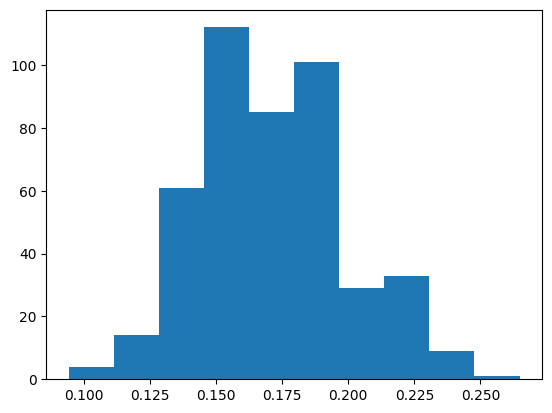

In [35]:
plt.hist(np.asarray(handle_p_sum))